# **Prediction of Students Performance in Exams**

Building: a predictive model to predict the math score of a student based on other variables such as gender, race/ethnicity, parental level of education, lunch, and test preparation course

Importing the necessary libraries first

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Reading the dataset

In [45]:
df = pd.read_csv('/content/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Initial Analysis of the dataset

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [47]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [48]:
df.duplicated().sum()

np.int64(0)

1. Dataset is having 1000 entries.
2. Dataset has no null values.
3. Dataset is carrying no duplicates.

## Now looking at numbers of the categorical features

In [49]:
df['gender'].value_counts()

,count
gender,
female,518
male,482


Almost balanced in gender

In [50]:
df['race/ethnicity'].value_counts()

,count
race/ethnicity,
group C,319
group D,262
group B,190
group E,140
group A,89


Data imbalanced accross categories but not that extremely, so still usable without corrections

In [51]:
df['parental level of education'].value_counts()

,count
parental level of education,
some college,226
associate's degree,222
high school,196
some high school,179
bachelor's degree,118
master's degree,59


Same level of imbalance as the above one, and is safe to use

In [52]:
df['lunch'].value_counts()

,count
lunch,
standard,645
free/reduced,355


In [53]:
df['test preparation course'].value_counts()

,count
test preparation course,
none,642
completed,358


Both lunch and test preparation course are safe to use

## Graphical representation of the counts

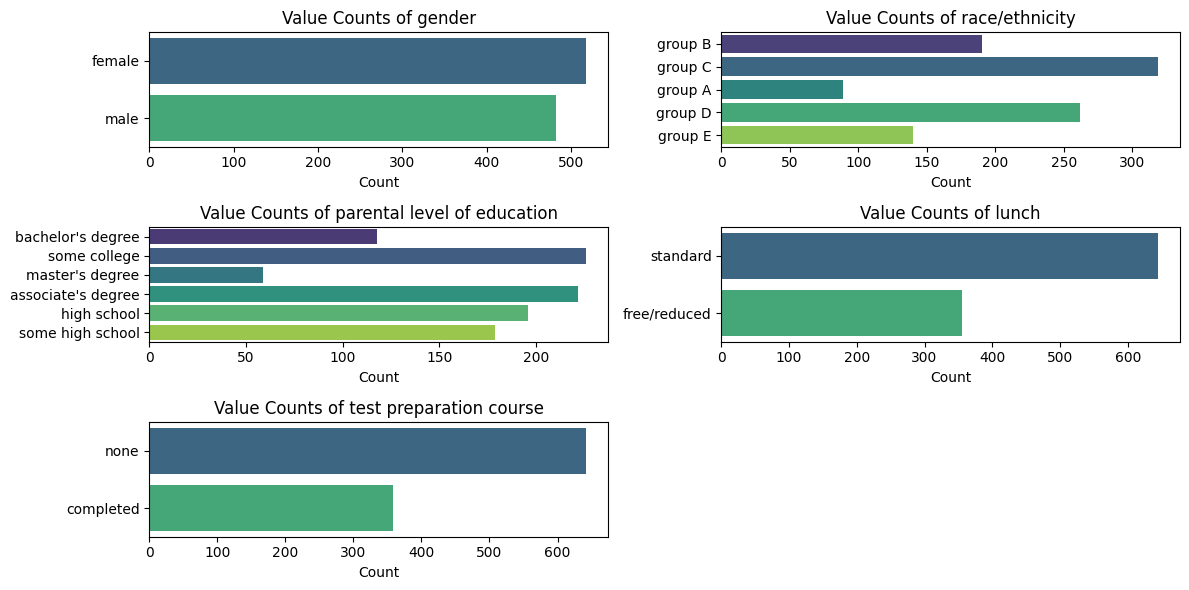

In [54]:
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

plt.figure(figsize=(12,6))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 2, i + 1)
    sns.countplot(y=col, data=df, hue=col, palette='viridis', legend=False)
    plt.title(f'Value Counts of {col}')
    plt.xlabel('Count')
    plt.ylabel('')

plt.tight_layout()
plt.show()

## Scoring Distribution

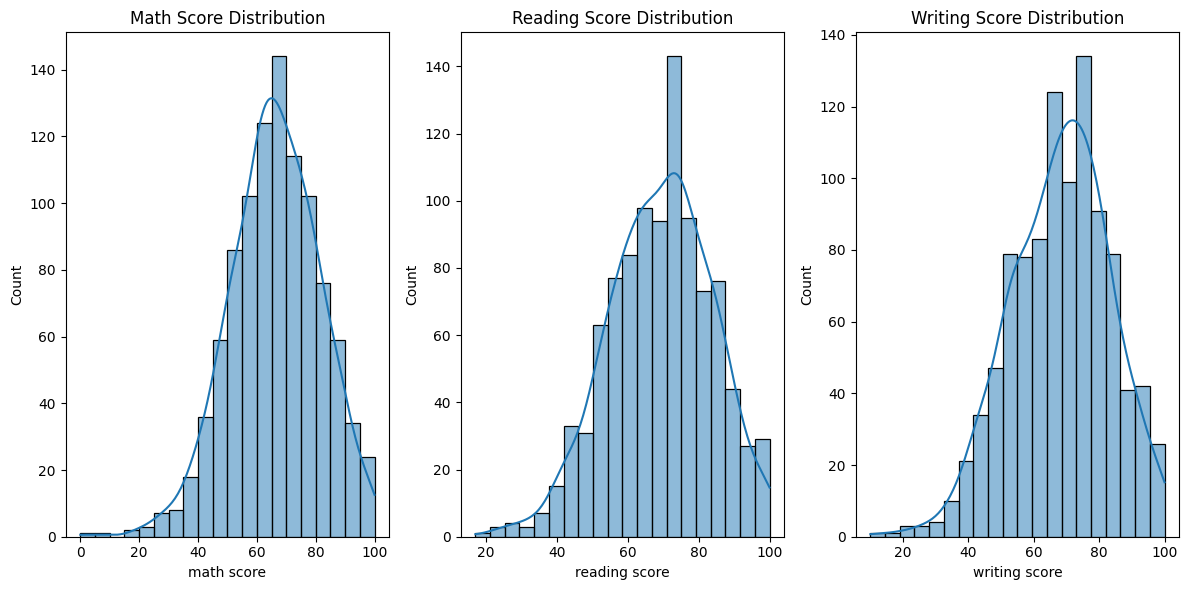

In [55]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.histplot(df['math score'], bins=20, kde=True)
plt.title('Math Score Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['reading score'], bins=20, kde=True)
plt.title('Reading Score Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['writing score'], bins=20, kde=True)
plt.title('Writing Score Distribution')

plt.tight_layout()
plt.show()

Slight left skewed but near normal. Nor extreme skewness so ideal for this regressioan analysis.

## Statistical Analysis

In [56]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


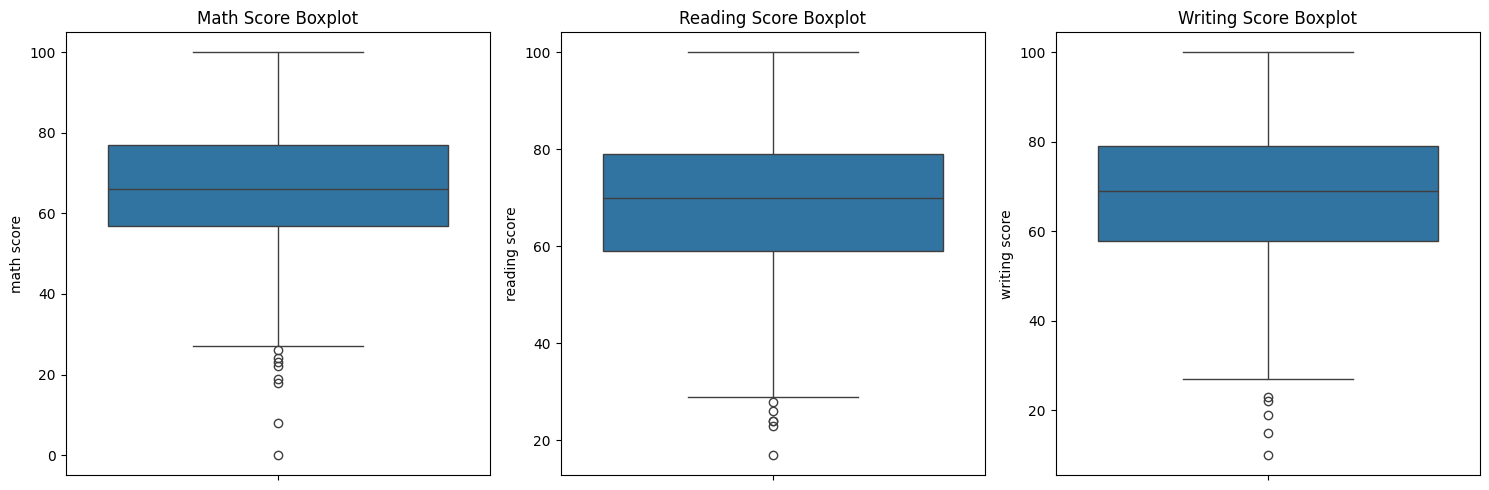

In [57]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y='math score', data=df)
plt.title('Math Score Boxplot')

plt.subplot(1, 3, 2)
sns.boxplot(y='reading score', data=df)
plt.title('Reading Score Boxplot')

plt.subplot(1, 3, 3)
sns.boxplot(y='writing score', data=df)
plt.title('Writing Score Boxplot')

plt.tight_layout()
plt.show()

There are some outliers getting marks arround 0-30 but removing them would make it biased towards only the good students. So we will keep them.

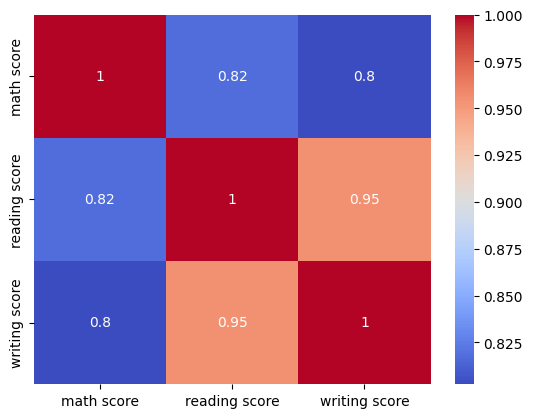

In [58]:
sns.heatmap (df.corr(numeric_only = True),annot=True, cmap = 'coolwarm')
plt.show()

## **Important understanding from the above heatmap**

Since math score is being higly correlated with reading and writing score, probably due to factors yet unknown to us like IQ.

Reading score and writing score has a correlation of 0.95, which s so extreme one might say its a duplicated column.

This results in extreme multicollinearity and may seem to increase the accuracy of the predicted model but these features are unreliable.

So removing them from input data seems fair on the model, even if accuracy might get affected.

We can also combine the reading and writing scores into one as average score, and use that to drive the model too.

We will be using both and decide which is best.

So X1 and Y1 for the one with scores dropped.

And X2 and Y2 for the one with scores included as average.

In [59]:
# Startegy 1: Drop all scores
X1 = df.drop(['reading score', 'writing score', 'math score'], axis=1)
Y1 = df['math score']


# Startegy 2: Take average of the reading and writing score then drop
df1 = df.copy()  # Make a copy of the dataset so as not to change the original
df1['Avg Score'] = ( df1['reading score'] + df1['writing score'] ) / 2
X2 = df1.drop(['reading score', 'writing score', 'math score'], axis=1)
Y2 = df1['math score']

In [60]:
df.head ()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Bit about the dataset's features:

Gender and Race/ethnicity is taken so as not be be biased towards a certain groups of individual and diversity is maintained to ensure fairness of this prediction model. These needs one-hot encoding as it isnt having any hierarchy or order.

Parental Level of education seems like its ordered categorical, thus label-encoding or manual way is needed as it is having heirarchy.

The lunch indicates a financial disparity. Standard lunch is something students can afford, thus denoting a level of  financial stability as compared to those depending on givt for free/reduced meals. So this also needs label-encoding or manual way is needed as it is having heirarchy in financial condition, which can be a factor to decide the target math score prediction.

The test preparation column seems ordered but s binary, so correct approoach would be to manually encode it to avod ambiguity.

Actually all should be manually encoded without label encoder.

## **STRATEGY 1**

In [61]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd # Ensure pandas is imported

le = LabelEncoder()

# Initialize OneHotEncoder to return dense arrays and handle unknown categories
ohe_gender = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# One-hot encode 'gender'
gender_encoded = ohe_gender.fit_transform(X1[['gender']])
# Create a DataFrame for the encoded 'gender' columns
gender_df = pd.DataFrame(gender_encoded, columns=ohe_gender.get_feature_names_out(['gender']), index=X1.index)
# Drop the original 'gender' column and concatenate the new encoded columns to X1
X1 = pd.concat([X1.drop('gender', axis=1), gender_df], axis=1)

# Initialize a new OneHotEncoder for 'race/ethnicity' to ensure it fits only on its categories
ohe_race = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# One-hot encode 'race/ethnicity'
race_encoded = ohe_race.fit_transform(X1[['race/ethnicity']])
# Create a DataFrame for the encoded 'race/ethnicity' columns
race_df = pd.DataFrame(race_encoded, columns=ohe_race.get_feature_names_out(['race/ethnicity']), index=X1.index)
# Drop the original 'race/ethnicity' column and concatenate the new encoded columns to X1
X1 = pd.concat([X1.drop('race/ethnicity', axis=1), race_df], axis=1)

X1.head()

,parental level of education,lunch,test preparation course,gender_female,gender_male,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,bachelor's degree,standard,none,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,some college,standard,completed,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,master's degree,standard,none,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,associate's degree,free/reduced,none,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,some college,standard,none,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [62]:
df['parental level of education'].value_counts()

,count
parental level of education,
some college,226
associate's degree,222
high school,196
some high school,179
bachelor's degree,118
master's degree,59


In [63]:
education_order = {"some college" : 2,
                   "associate's degree" : 3,
                   "high school" : 1,
                   "some high school" : 0,
                   "bachelor's degree" : 4,
                   "master's degree" : 5
                   }
X1['parental level of education'] = X1['parental level of education'].map(education_order)
X1.head()

,parental level of education,lunch,test preparation course,gender_female,gender_male,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,4,standard,none,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,standard,completed,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,5,standard,none,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,3,free/reduced,none,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,2,standard,none,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [64]:
lunch_coded = {
    "standard": 1,
    "free/reduced": 0
}

X1['lunch'] = X1['lunch'].map(lunch_coded)

prep_coded = {
    "completed": 1,
    "none": 0
}

X1['test preparation course'] = X1['test preparation course'].map(prep_coded)

X1.head()

,parental level of education,lunch,test preparation course,gender_female,gender_male,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,4,1,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,1,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,5,1,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,3,0,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,2,1,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


Need to drop a gender_male so as to get rid of the multicollinearity arising fom the high near perfect -ve correlation between gender_male and gender_female

In [65]:
X1 = X1.drop('gender_male', axis=1)
X1.head()

,parental level of education,lunch,test preparation course,gender_female,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,4,1,0,1.0,0.0,1.0,0.0,0.0,0.0
1,2,1,1,1.0,0.0,0.0,1.0,0.0,0.0
2,5,1,0,1.0,0.0,1.0,0.0,0.0,0.0
3,3,0,0,0.0,1.0,0.0,0.0,0.0,0.0
4,2,1,0,0.0,0.0,0.0,1.0,0.0,0.0


Strategy 1 input features seems ready to be fed into training

In [66]:
!pip install catboost

## Now importing all the models we are going to try

In [67]:
# importing the cross val score and models

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import (RandomForestRegressor,
                              ExtraTreesRegressor,
                              GradientBoostingRegressor,
                              AdaBoostRegressor)
from sklearn.linear_model import (LinearRegression,
                                  Ridge,
                                  Lasso,
                                  ElasticNet)
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Define models
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "GradientBoost": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "XGBoost": XGBRegressor(verbosity=0),
    "LightGBM": LGBMRegressor(),
    "CatBoost": CatBoostRegressor(verbose=0)
}

# Loop through models
results = []

for name, model in models.items():
    scores = cross_val_score(model, X1, Y1, cv=5, scoring='r2')

    mean_score = scores.mean()
    std_score = scores.std()

    results.append((name, mean_score))

    print(f"{name}: Mean R2 = {mean_score:.4f}, Std = {std_score:.4f}")

# Sort results (best model on top)
print("\n--- Sorted Results ---")
results.sort(key=lambda x: x[1], reverse=True)

for name, score in results:
    print(f"{name}: {score:.4f}")

Linear: Mean R2 = 0.2309, Std = 0.0410
Ridge: Mean R2 = 0.2311, Std = 0.0407
Lasso: Mean R2 = 0.1416, Std = 0.0224
ElasticNet: Mean R2 = 0.0979, Std = 0.0171
DecisionTree: Mean R2 = -0.0759, Std = 0.0428
RandomForest: Mean R2 = 0.0142, Std = 0.0334
ExtraTrees: Mean R2 = -0.0659, Std = 0.0396
GradientBoost: Mean R2 = 0.1561, Std = 0.0485
AdaBoost: Mean R2 = 0.1561, Std = 0.0528
XGBoost: Mean R2 = -0.0690, Std = 0.0443
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000304 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 9
[LightGBM] [Info] Start training from score 66.540000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

R2 value is 0.2311 max for ridge regression

# **Champion Model in strategy 1 is Ridge Regression**

## **Strategy 2**

In [68]:
X2.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,Avg Score
0,female,group B,bachelor's degree,standard,none,73.0
1,female,group C,some college,standard,completed,89.0
2,female,group B,master's degree,standard,none,94.0
3,male,group A,associate's degree,free/reduced,none,50.5
4,male,group C,some college,standard,none,76.5


In [69]:
from sklearn.preprocessing import OneHotEncoder

# One-hot encode 'gender' for X2
ohe_gender_X2 = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
gender_encoded_X2 = ohe_gender_X2.fit_transform(X2[['gender']])
gender_df_X2 = pd.DataFrame(gender_encoded_X2, columns=ohe_gender_X2.get_feature_names_out(['gender']), index=X2.index)
X2 = pd.concat([X2.drop('gender', axis=1), gender_df_X2], axis=1)

# One-hot encode 'race/ethnicity' for X2
ohe_race_X2 = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
race_encoded_X2 = ohe_race_X2.fit_transform(X2[['race/ethnicity']])
race_df_X2 = pd.DataFrame(race_encoded_X2, columns=ohe_race_X2.get_feature_names_out(['race/ethnicity']), index=X2.index)
X2 = pd.concat([X2.drop('race/ethnicity', axis=1), race_df_X2], axis=1)

X2.head()

,parental level of education,lunch,test preparation course,Avg Score,gender_female,gender_male,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,bachelor's degree,standard,none,73.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,some college,standard,completed,89.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,master's degree,standard,none,94.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,associate's degree,free/reduced,none,50.5,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,some college,standard,none,76.5,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [70]:
education_order = {"some college" : 2,
                   "associate's degree" : 3,
                   "high school" : 1,
                   "some high school" : 0,
                   "bachelor's degree" : 4,
                   "master's degree" : 5
                   }
X2['parental level of education'] = X2['parental level of education'].map(education_order)

lunch_coded = {
    "standard": 1,
    "free/reduced": 0
}

X2['lunch'] = X2['lunch'].map(lunch_coded)

prep_coded = {
    "completed": 1,
    "none": 0
}

X2['test preparation course'] = X2['test preparation course'].map(prep_coded)

X2.head()

,parental level of education,lunch,test preparation course,Avg Score,gender_female,gender_male,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,4,1,0,73.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,1,1,89.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,5,1,0,94.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,3,0,0,50.5,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,2,1,0,76.5,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [71]:
X2 = X2.drop('gender_male' , axis = 1)
X2.head ()

,parental level of education,lunch,test preparation course,Avg Score,gender_female,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,4,1,0,73.0,1.0,0.0,1.0,0.0,0.0,0.0
1,2,1,1,89.0,1.0,0.0,0.0,1.0,0.0,0.0
2,5,1,0,94.0,1.0,0.0,1.0,0.0,0.0,0.0
3,3,0,0,50.5,0.0,1.0,0.0,0.0,0.0,0.0
4,2,1,0,76.5,0.0,0.0,0.0,1.0,0.0,0.0


In [72]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale only Avg Score
X2['Avg Score'] = scaler.fit_transform(X2[['Avg Score']])

X2.head()

,parental level of education,lunch,test preparation course,Avg Score,gender_female,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,4,1,0,0.298120,1.0,0.0,1.0,0.0,0.0,0.0
1,2,1,1,1.385036,1.0,0.0,0.0,1.0,0.0,0.0
2,5,1,0,1.724697,1.0,0.0,1.0,0.0,0.0,0.0
3,3,0,0,-1.230354,0.0,1.0,0.0,0.0,0.0,0.0
4,2,1,0,0.535883,0.0,0.0,0.0,1.0,0.0,0.0


Ready to be fed into models

In [75]:
from sklearn.model_selection import cross_val_score

# Define models
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "GradientBoost": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "XGBoost": XGBRegressor(verbosity=0),
    "LightGBM": LGBMRegressor(),
    "CatBoost": CatBoostRegressor(verbose=0)
}

# Loop through models
results = []

for name, model in models.items():
    scores = cross_val_score(model, X2, Y2, cv=5, scoring='r2')

    mean_score = scores.mean()
    std_score = scores.std()

    results.append((name, mean_score))

    print(f"{name}: Mean R2 = {mean_score:.4f}, Std = {std_score:.4f}")

# Sort results
print("\nSorted Results")
results.sort(key=lambda x: x[1], reverse=True)

for name, score in results:
    print(f"{name}: {score:.4f}")

Linear: Mean R2 = 0.8692, Std = 0.0158
Ridge: Mean R2 = 0.8692, Std = 0.0158
Lasso: Mean R2 = 0.8092, Std = 0.0224
ElasticNet: Mean R2 = 0.6499, Std = 0.0153
DecisionTree: Mean R2 = 0.7138, Std = 0.0497
RandomForest: Mean R2 = 0.8231, Std = 0.0280
ExtraTrees: Mean R2 = 0.8029, Std = 0.0321
GradientBoost: Mean R2 = 0.8518, Std = 0.0240
AdaBoost: Mean R2 = 0.8244, Std = 0.0196
XGBoost: Mean R2 = 0.7866, Std = 0.0321
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 130
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 10
[LightGBM] [Info] Start training from score 66.540000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

Huge jump in R2 value

# **Champion Model in strategy 2 is Ridge Regression**

## Ridge, Linear and GradientBoost were the top 3 models for both strategies

Simple linear regression with regularization beat the complex algorithms as the data in itself is pretty linear and well organized.

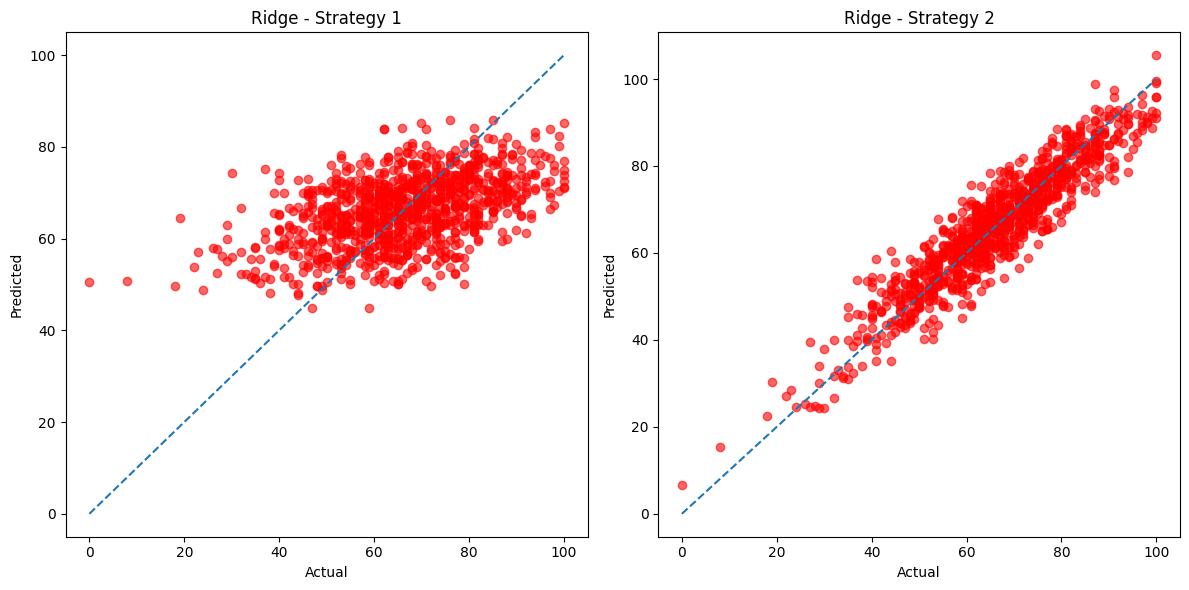

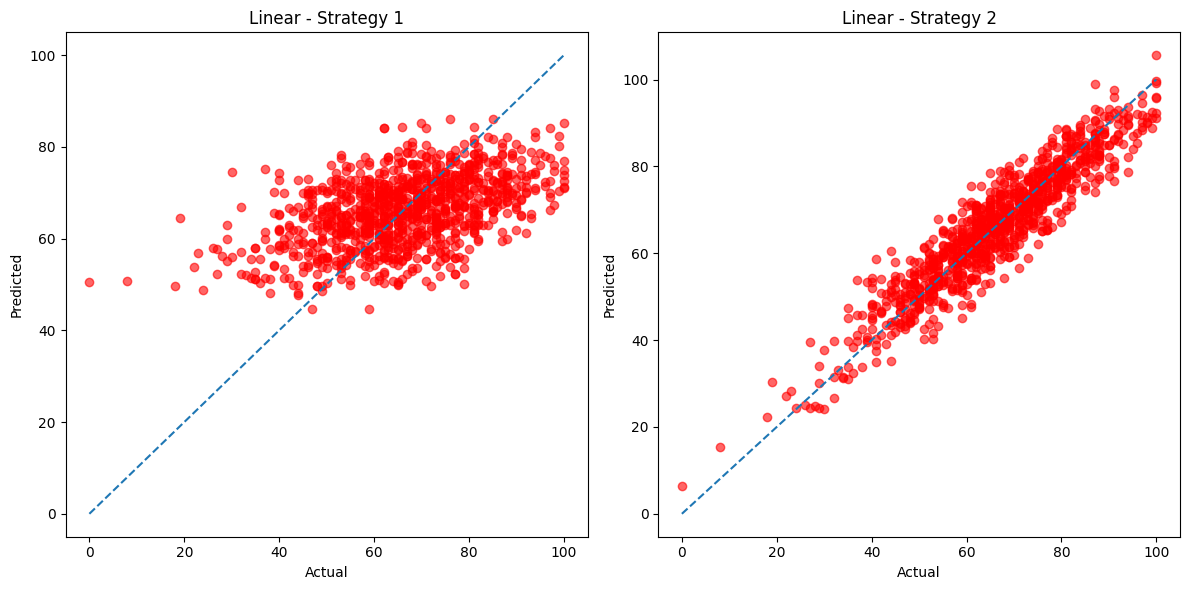

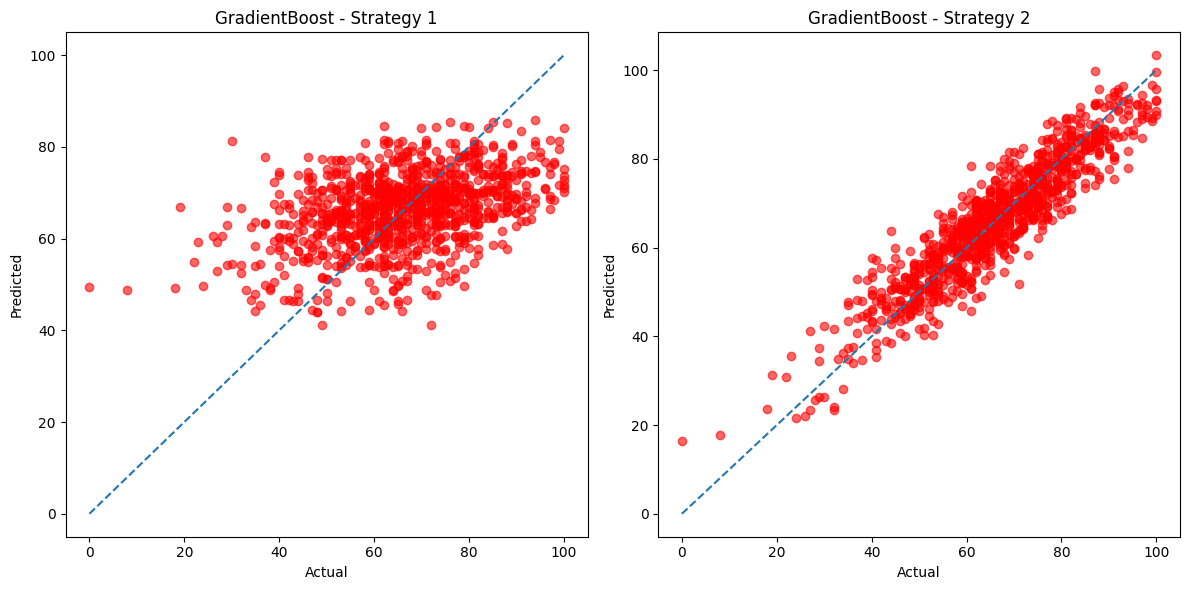

In [78]:
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt

top_models = {
    "Ridge": Ridge(),
    "Linear": LinearRegression(),
    "GradientBoost": GradientBoostingRegressor()
}

for name, model in top_models.items():

    # Strategy 1 predictions
    y1_pred = cross_val_predict(model, X1, Y1, cv=5)

    # Strategy 2 predictions
    y2_pred = cross_val_predict(model, X2, Y2, cv=5)

    plt.figure(figsize=(12,6))

    # Strategy 1
    plt.subplot(1,2,1)
    plt.scatter(Y1, y1_pred, alpha=0.6 , color = 'red')
    plt.plot([0,100], [0,100], linestyle='--')
    plt.title(f"{name} - Strategy 1")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

    # Strategy 2
    plt.subplot(1,2,2)
    plt.scatter(Y2, y2_pred, alpha=0.6 , color = 'red')
    plt.plot([0,100], [0,100], linestyle='--')
    plt.title(f"{name} - Strategy 2")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

    plt.tight_layout()
    plt.show()

## **BEST MODEL = RIDGE**

Train Final Model on Full Data

In [79]:
from sklearn.linear_model import Ridge

final_model = Ridge()
final_model.fit(X2, Y2)

Ridge()

Final Predictions

In [80]:
y_pred = final_model.predict(X2)

Evaluation Metrics

In [81]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(Y2, y_pred)
rmse = np.sqrt(mean_squared_error(Y2, y_pred))

print("Final Model Performance:")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

Final Model Performance:
R2 Score: 0.8728
RMSE: 5.4050


87% of variations in math score is explained by the model when using strategy 2 on the ridge.

RMSE = 5.4 means predictions are off by +- 5 marks.

Feature importance (Coefficients)

In [82]:
coefficients = pd.DataFrame({
    "Feature": X2.columns,
    "Coefficient": final_model.coef_
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

print("\nFeature Importance (Ridge Coefficients):")
print(coefficients)


Feature Importance (Ridge Coefficients):
                       Feature  Coefficient
3                    Avg Score    14.059733
9       race/ethnicity_group E     3.737688
1                        lunch     3.495761
0  parental level of education    -0.282202
6       race/ethnicity_group B    -0.501402
8       race/ethnicity_group D    -0.796822
7       race/ethnicity_group C    -1.086006
5       race/ethnicity_group A    -1.353459
2      test preparation course    -2.839033
4                gender_female   -12.680847


Plot Feature Importance

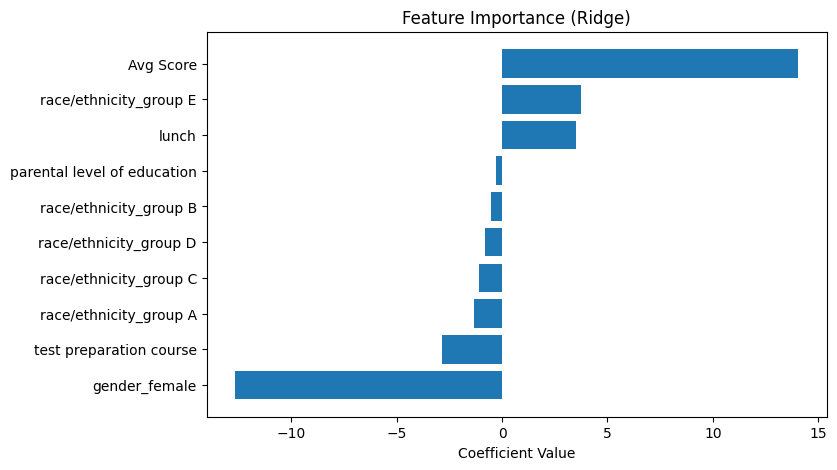

In [83]:
plt.figure(figsize=(8,5))
plt.barh(coefficients["Feature"], coefficients["Coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Feature Importance (Ridge)")
plt.gca().invert_yaxis()
plt.show()

1. Avg Score is most important feature.

2. gender_female = -12 means compared to baseline (males) coefficient is lower.

3. Lunch = 3.49 means students with better lunch (standard) performed better.

4. Test prep = -2.83 means students without it performed worse.

5. Race and ethinicity seems to have weaker effect, as it has mixed values.

Final Actual vs Predicted Plot

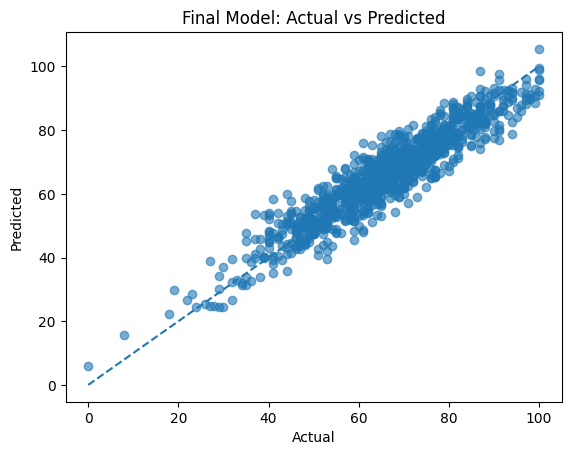

In [84]:
plt.scatter(Y2, y_pred, alpha=0.6)
plt.plot([0,100], [0,100], linestyle='--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Final Model: Actual vs Predicted")
plt.show()

Residual Plot

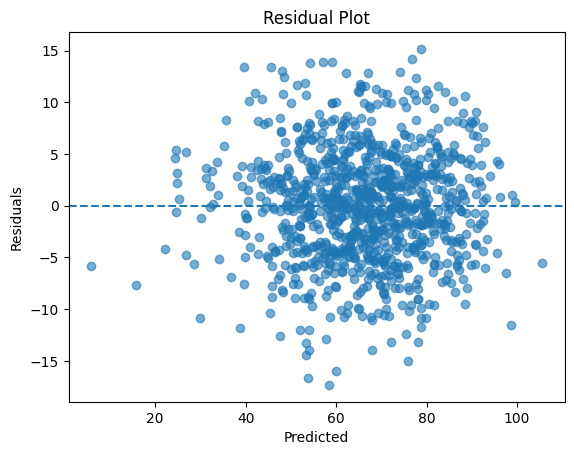

In [85]:
residuals = Y2 - y_pred

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

We see without the scores in strategy 1 we had R2 = 0.23 which isn't a good model.

So using strategy 2 and taking the avg_scores we get a way better model.

**Saving Model**

In [86]:
import joblib

joblib.dump(final_model, "ridge_model.pkl")

['ridge_model.pkl']

# **📌 Conclusion**

In this project, a predictive model was developed to estimate students’ math scores using demographic and academic features.

Initially, models trained on the original features (Strategy 1) showed poor performance (R² ≈ 0.23), indicating that the available variables were not sufficient to capture the underlying relationship with math scores.

To address this, a new feature — Average Score (mean of reading and writing scores) — was engineered (Strategy 2). This significantly improved model performance (R² ≈ 0.87), demonstrating that math performance is strongly correlated with reading and writing abilities.

Multiple regression models were evaluated using cross-validation. Among them, Ridge Regression performed best, achieving high accuracy with stable and consistent results. The strong performance of linear models suggests that the relationship between features and the target variable is largely linear.

Feature importance analysis revealed that:

- Average Score is the most influential predictor of math performance
- Lunch type (proxy for economic condition) has a noticeable impact
- Test preparation and parental education contribute moderately
- Other demographic features have relatively smaller effects

Residual analysis confirmed that the model does not exhibit major bias, with errors distributed randomly around zero.

Overall, this project highlights that:

- Feature engineering has a greater impact than model complexity
- Simple, well-structured models can outperform complex ones when relationships are linear

The final model demonstrates strong predictive capability and can be effectively used to estimate student math performance.